In [40]:
import pandas as pd

df=pd.read_csv("Daily_Water_Intake.csv")
df

,Age,Gender,Weight (kg),Daily Water Intake (liters),Physical Activity Level,Weather,Hydration Level
0,56,Male,96,4.23,Moderate,Hot,Good
1,60,Male,105,3.95,High,Normal,Good
2,36,Male,68,2.39,Moderate,Cold,Good
3,19,Female,74,3.13,Moderate,Hot,Good
4,38,Male,77,2.11,Low,Normal,Poor
...,...,...,...,...,...,...,...
29995,47,Male,97,3.45,Moderate,Cold,Good
29996,49,Female,109,5.32,High,Hot,Good
29997,56,Female,54,1.50,Moderate,Cold,Poor
29998,36,Male,106,4.00,Low,Hot,Good


In [41]:
df.shape

(30000, 7)

In [42]:
df.columns

Index(['Age', 'Gender', 'Weight (kg)', 'Daily Water Intake (liters)',
       'Physical Activity Level', 'Weather', 'Hydration Level'],
      dtype='object')

In [43]:
df.dtypes

Age                              int64
Gender                          object
Weight (kg)                      int64
Daily Water Intake (liters)    float64
Physical Activity Level         object
Weather                         object
Hydration Level                 object
dtype: object

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Age                          30000 non-null  int64  
 1   Gender                       30000 non-null  object 
 2   Weight (kg)                  30000 non-null  int64  
 3   Daily Water Intake (liters)  30000 non-null  float64
 4   Physical Activity Level      30000 non-null  object 
 5   Weather                      30000 non-null  object 
 6   Hydration Level              30000 non-null  object 
dtypes: float64(1), int64(2), object(4)
memory usage: 1.6+ MB


In [45]:
df.describe()

,Age,Weight (kg),Daily Water Intake (liters)
count,30000.000000,30000.00000,30000.000000
mean,43.467667,76.84860,2.852444
std,14.998940,18.74494,0.835537
min,18.000000,45.00000,1.500000
25%,30.000000,61.00000,2.220000
50%,43.000000,77.00000,2.830000
75%,56.000000,93.00000,3.440000
max,69.000000,109.00000,5.430000


In [46]:
df["Gender"].value_counts()

Gender
Male      15032
Female    14968
Name: count, dtype: int64

In [47]:
df["Physical Activity Level"].value_counts()

Physical Activity Level
High        10069
Low         10011
Moderate     9920
Name: count, dtype: int64

In [48]:
df["Weather"].value_counts()

Weather
Hot       10081
Cold      10012
Normal     9907
Name: count, dtype: int64

In [49]:
df["Hydration Level"].value_counts()

Hydration Level
Good    23915
Poor     6085
Name: count, dtype: int64

In [50]:
df.head()

,Age,Gender,Weight (kg),Daily Water Intake (liters),Physical Activity Level,Weather,Hydration Level
0,56,Male,96,4.23,Moderate,Hot,Good
1,60,Male,105,3.95,High,Normal,Good
2,36,Male,68,2.39,Moderate,Cold,Good
3,19,Female,74,3.13,Moderate,Hot,Good
4,38,Male,77,2.11,Low,Normal,Poor


In [51]:
df.tail()

,Age,Gender,Weight (kg),Daily Water Intake (liters),Physical Activity Level,Weather,Hydration Level
29995,47,Male,97,3.45,Moderate,Cold,Good
29996,49,Female,109,5.32,High,Hot,Good
29997,56,Female,54,1.50,Moderate,Cold,Poor
29998,36,Male,106,4.00,Low,Hot,Good
29999,26,Female,98,4.43,Moderate,Hot,Good


In [52]:
df.sample(5)

,Age,Gender,Weight (kg),Daily Water Intake (liters),Physical Activity Level,Weather,Hydration Level
11391,58,Male,63,2.91,High,Normal,Good
5625,58,Male,106,3.81,Moderate,Hot,Good
20162,24,Female,71,3.42,Moderate,Hot,Good
11346,43,Female,56,2.19,Low,Hot,Good
19489,41,Male,98,4.13,High,Normal,Good


In [53]:
df.isna().sum()

Age                            0
Gender                         0
Weight (kg)                    0
Daily Water Intake (liters)    0
Physical Activity Level        0
Weather                        0
Hydration Level                0
dtype: int64

In [54]:
df.duplicated().sum()

np.int64(338)

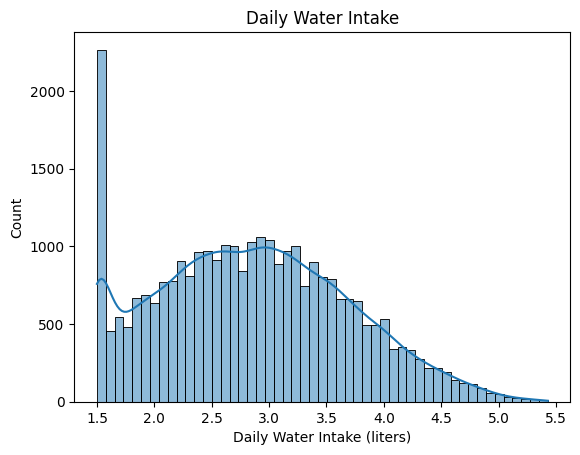

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df["Daily Water Intake (liters)"], kde=True)
plt.title("Daily Water Intake")
plt.show()

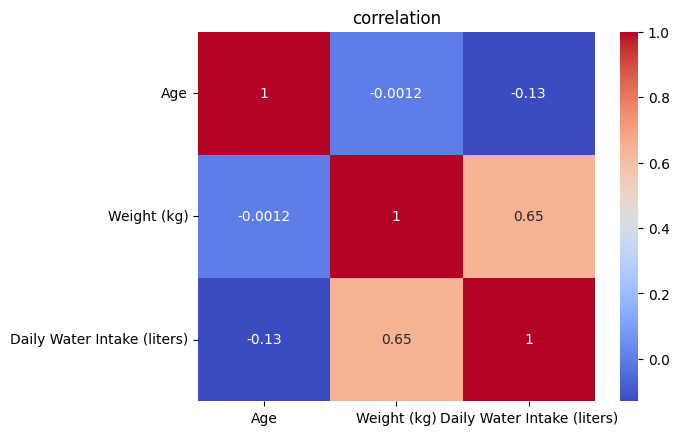

In [56]:
num_features=df[["Age", "Weight (kg)", "Daily Water Intake (liters)"]]
corr=num_features.corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("correlation")
plt.show()

In [57]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier

# ==============================
# 🔥 1. FEATURE ENGINEERING
# ==============================

# Rasio air terhadap berat
df["Water_per_Weight"] = df["Daily Water Intake (liters)"] / df["Weight (kg)"]

# Mapping untuk activity
activity_map = {"Low": 1, "Moderate": 2, "High": 3}
df["Activity_num"] = df["Physical Activity Level"].map(activity_map)

# Mapping untuk weather
weather_map = {"Cold": 1, "Normal": 2, "Hot": 3}
df["Weather_num"] = df["Weather"].map(weather_map)

# Interaksi fitur
df["Activity_Water"] = df["Daily Water Intake (liters)"] * df["Activity_num"]
df["Weather_Water"] = df["Daily Water Intake (liters)"] * df["Weather_num"]
df["Weight_x_Activity"] = df["Weight (kg)"] * df["Activity_num"]

# ==============================
# 🧹 2. (OPSIONAL) HAPUS OUTLIER
# ==============================

Q1 = df["Daily Water Intake (liters)"].quantile(0.25)
Q3 = df["Daily Water Intake (liters)"].quantile(0.75)
IQR = Q3 - Q1

df = df[(df["Daily Water Intake (liters)"] >= Q1 - 1.5*IQR) & 
        (df["Daily Water Intake (liters)"] <= Q3 + 1.5*IQR)]

# ==============================
# 🎯 3. DEFINISI FITUR & TARGET
# ==============================

X = df[
    [
        "Age",
        "Weight (kg)",
        "Daily Water Intake (liters)",
        "Water_per_Weight",
        "Activity_Water",
        "Weather_Water",
        "Weight_x_Activity",
        "Gender",
        "Physical Activity Level",
        "Weather"
    ]
]

y = df["Hydration Level"]

# ==============================
# ✂️ 4. SPLIT DATA
# ==============================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==============================
# ⚙️ 5. PREPROCESSING
# ==============================

numeric_columns = [
    "Age",
    "Weight (kg)",
    "Daily Water Intake (liters)",
    "Water_per_Weight",
    "Activity_Water",
    "Weather_Water",
    "Weight_x_Activity"
]

categorical_columns = ["Gender", "Weather"]
ordinal_columns = ["Physical Activity Level"]

activity_order = [["Low", "Moderate", "High"]]

preprocessing = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_columns),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns),
        ("ord", OrdinalEncoder(categories=activity_order), ordinal_columns)
    ]
)

# ==============================
# 🌲 6. MODEL (LEBIH KUAT)
# ==============================

model = Pipeline(
    steps=[
        ("preprocessing", preprocessing),
        ("model", RandomForestClassifier(random_state=42))
    ]
)

# ==============================
# 🔥 7. HYPERPARAMETER TUNING
# ==============================

param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [5, 10, None],
    "model__min_samples_split": [2, 5]
}

grid = GridSearchCV(model, param_grid, cv=5, n_jobs=-1)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_

# ==============================
# 📊 8. EVALUASI
# ==============================

y_pred = best_model.predict(X_test)

print("Best Params:", grid.best_params_)
print("\nAccuracy Score:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# ==============================
# 📈 9. CROSS VALIDATION
# ==============================

cv_scores = cross_val_score(best_model, X, y, cv=5)
print("\nCross Validation Accuracy:", cv_scores.mean())

Best Params: {'model__max_depth': 5, 'model__min_samples_split': 2, 'model__n_estimators': 100}

Accuracy Score: 1.0

Classification Report:
               precision    recall  f1-score   support

        Good       1.00      1.00      1.00      4777
        Poor       1.00      1.00      1.00      1219

    accuracy                           1.00      5996
   macro avg       1.00      1.00      1.00      5996
weighted avg       1.00      1.00      1.00      5996


Confusion Matrix:
 [[4777    0]
 [   0 1219]]

Cross Validation Accuracy: 1.0


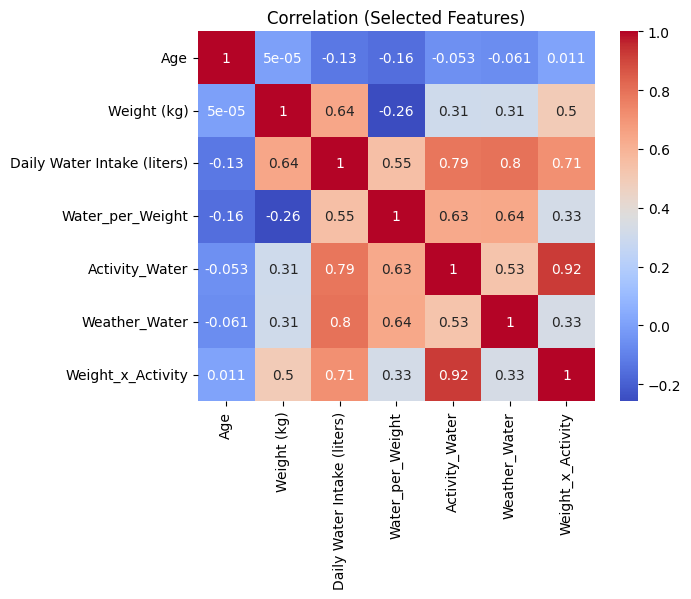

In [58]:
num_features = df[
    [
        "Age",
        "Weight (kg)",
        "Daily Water Intake (liters)",
        "Water_per_Weight",
        "Activity_Water",
        "Weather_Water",
        "Weight_x_Activity"
    ]
]

corr = num_features.corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation (Selected Features)")
plt.show()

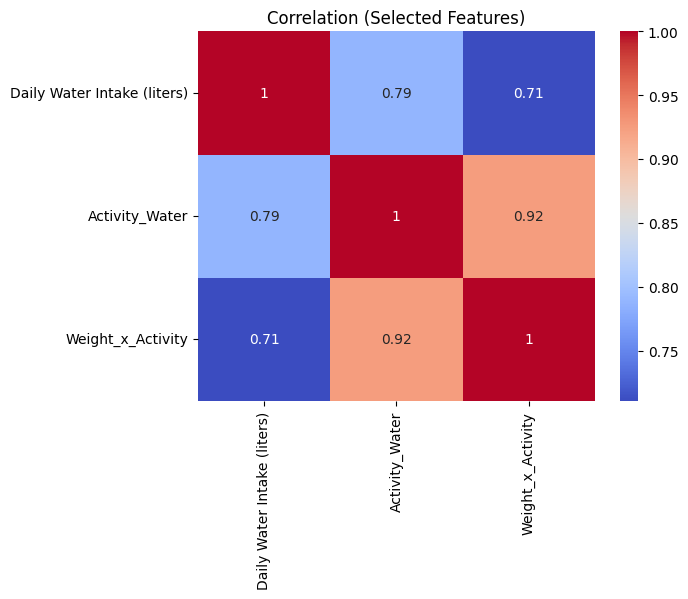

In [59]:
num_features = df[["Daily Water Intake (liters)", "Activity_Water", "Weight_x_Activity"]]

corr = num_features.corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation (Selected Features)")
plt.show()

In [60]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

X = df[["Age", "Gender", "Weight (kg)", "Daily Water Intake (liters)", "Physical Activity Level", "Weather"]]
y = df["Hydration Level"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

numeric_columns = ["Age", "Weight (kg)", "Daily Water Intake (liters)"]
categorical_columns = ["Gender", "Weather"]
ordinal_columns = ["Physical Activity Level"]

activity_order = ["Low", "Moderate", "High"]
ordinal_order = [activity_order]

preprocessing = ColumnTransformer(
    transformers=[
        ("scaler", StandardScaler(), numeric_columns),
        ("ohe", OneHotEncoder(), categorical_columns),
        ("oe", OrdinalEncoder(categories=ordinal_order), ordinal_columns)
    ]
)

model = Pipeline(
    steps=[
        ("preprocessing", preprocessing),
        ("model", LogisticRegression())
    ]
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy Score : ", accuracy_score(y_test, y_pred))
print("Classification Report :\n", classification_report(y_test, y_pred))
print("Confusion Matrix :\n", confusion_matrix(y_test, y_pred))

Accuracy Score :  0.9983322214809873
Classification Report :
               precision    recall  f1-score   support

        Good       1.00      1.00      1.00      4777
        Poor       1.00      0.99      1.00      1219

    accuracy                           1.00      5996
   macro avg       1.00      1.00      1.00      5996
weighted avg       1.00      1.00      1.00      5996

Confusion Matrix :
 [[4777    0]
 [  10 1209]]


In [61]:
# =========================================================
# IMPORT LIBRARY MACHINE LEARNING
# =========================================================

# Model klasifikasi Logistic Regression
from sklearn.linear_model import LogisticRegression

# Digunakan untuk membagi dataset menjadi data training dan testing
# serta evaluasi model menggunakan cross validation
from sklearn.model_selection import train_test_split, cross_val_score

# Digunakan untuk mengukur performa model klasifikasi
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Tools preprocessing untuk mengubah data agar bisa dipahami model ML
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

# Pipeline digunakan untuk menggabungkan preprocessing dan model
# sehingga proses training dan prediction menjadi satu alur otomatis
from sklearn.pipeline import Pipeline

# ColumnTransformer digunakan untuk menerapkan preprocessing berbeda
# pada kolom numerik, kategorikal, dan ordinal
from sklearn.compose import ColumnTransformer

# Model alternatif untuk klasifikasi (belum digunakan di kode ini)
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier


# =========================================================
# MEMISAHKAN FEATURE (X) DAN TARGET (y)
# =========================================================

# X adalah variabel input (feature) yang digunakan model untuk belajar
# Kolom yang digunakan adalah karakteristik individu dan lingkungan
X = df[[
    "Age",
    "Gender",
    "Weight (kg)",
    "Daily Water Intake (liters)",
    "Physical Activity Level",
    "Weather"
]]

# y adalah target yang ingin diprediksi oleh model
# Dalam kasus ini adalah tingkat hidrasi tubuh
y = df["Hydration Level"]


# =========================================================
# MEMBAGI DATA TRAINING DAN TESTING
# =========================================================

# Dataset dibagi menjadi:
# 80% data training -> untuk melatih model
# 20% data testing -> untuk menguji performa model

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,   # 20% data digunakan sebagai data testing
    random_state=42  # memastikan hasil split selalu sama setiap dijalankan
)


# =========================================================
# MENENTUKAN JENIS KOLOM DATA
# =========================================================

# Kolom numerik (berupa angka kontinu)
numeric_columns = [
    "Age",
    "Weight (kg)",
    "Daily Water Intake (liters)"
]

# Kolom kategorikal (tidak memiliki urutan)
categorical_columns = [
    "Gender",
    "Weather"
]

# Kolom ordinal (memiliki urutan logis)
ordinal_columns = [
    "Physical Activity Level"
]


# =========================================================
# MENENTUKAN URUTAN DATA ORDINAL
# =========================================================

# Urutan tingkat aktivitas fisik dari rendah ke tinggi
activity_order = ["Low", "Moderate", "High"]

# OrdinalEncoder membutuhkan format list of list
ordinal_order = [activity_order]


# =========================================================
# MEMBUAT PIPELINE PREPROCESSING
# =========================================================

# ColumnTransformer memungkinkan kita menerapkan preprocessing berbeda
# pada jenis kolom yang berbeda

preprocessing = ColumnTransformer(
    transformers=[

        # StandardScaler digunakan untuk menormalkan data numerik
        # agar memiliki skala yang sama
        ("scaler", StandardScaler(), numeric_columns),

        # OneHotEncoder mengubah kategori menjadi variabel biner
        # contoh: Male -> [1,0], Female -> [0,1]
        ("ohe", OneHotEncoder(), categorical_columns),

        # OrdinalEncoder mengubah kategori yang memiliki urutan
        # menjadi angka berdasarkan urutan yang ditentukan
        # Low = 0, Moderate = 1, High = 2
        ("oe", OrdinalEncoder(categories=ordinal_order), ordinal_columns)
    ]
)


# =========================================================
# MEMBUAT PIPELINE MACHINE LEARNING
# =========================================================

# Pipeline menggabungkan preprocessing dan model dalam satu proses
# sehingga saat predict() dilakukan, data otomatis diproses terlebih dahulu

model = Pipeline(
    steps=[

        # Langkah pertama adalah preprocessing data
        ("preprocessing", preprocessing),

        # Langkah kedua adalah model klasifikasi
        ("model", LogisticRegression())
    ]
)


# =========================================================
# TRAINING MODEL
# =========================================================

# Model dilatih menggunakan data training
# Pada tahap ini model belajar hubungan antara feature dan target
model.fit(X_train, y_train)


# =========================================================
# MELAKUKAN PREDIKSI
# =========================================================

# Model memprediksi hydration level pada data testing
y_pred = model.predict(X_test)


# =========================================================
# EVALUASI PERFORMA MODEL
# =========================================================

# Accuracy menghitung persentase prediksi yang benar
print("Accuracy Score : ", accuracy_score(y_test, y_pred))

# Classification Report memberikan metrik lengkap:
# Precision, Recall, dan F1-score untuk setiap kelas
print("Classification Report :\n", classification_report(y_test, y_pred))

# Confusion Matrix menunjukkan jumlah prediksi benar dan salah
# dalam bentuk matriks perbandingan antara label asli dan prediksi
print("Confusion Matrix :\n", confusion_matrix(y_test, y_pred))

Accuracy Score :  0.9983322214809873
Classification Report :
               precision    recall  f1-score   support

        Good       1.00      1.00      1.00      4777
        Poor       1.00      0.99      1.00      1219

    accuracy                           1.00      5996
   macro avg       1.00      1.00      1.00      5996
weighted avg       1.00      1.00      1.00      5996

Confusion Matrix :
 [[4777    0]
 [  10 1209]]


In [62]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

X = df[["Age", "Gender", "Weight (kg)", "Daily Water Intake (liters)", "Physical Activity Level", "Weather"]]
y = df["Hydration Level"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

numeric_columns = ["Age", "Weight (kg)", "Daily Water Intake (liters)"]
categorical_columns = ["Gender", "Weather"]
ordinal_columns = ["Physical Activity Level"]

activity_order = ["Low", "Moderate", "High"]
ordinal_order = [activity_order]

preprocessing = ColumnTransformer(
    transformers=[
        ("scaler", StandardScaler(), numeric_columns),
        ("ohe", OneHotEncoder(), categorical_columns),
        ("oe", OrdinalEncoder(categories=ordinal_order), ordinal_columns)
    ]
)

model_forest = Pipeline(
    steps=[
        ("preprocessing", preprocessing),
        ("model", RandomForestClassifier(random_state=42))
    ]
)

model_forest.fit(X_train, y_train)
y_pred = model_forest.predict(X_test)

print("Accuracy Score : ", accuracy_score(y_test, y_pred))
print("Classification Report :\n", classification_report(y_test, y_pred))
print("Confusion Matrix :\n", confusion_matrix(y_test, y_pred))

Accuracy Score :  0.9914943295530354
Classification Report :
               precision    recall  f1-score   support

        Good       0.99      1.00      0.99      4777
        Poor       0.98      0.98      0.98      1219

    accuracy                           0.99      5996
   macro avg       0.99      0.99      0.99      5996
weighted avg       0.99      0.99      0.99      5996

Confusion Matrix :
 [[4756   21]
 [  30 1189]]


In [63]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

X = df[["Age", "Gender", "Weight (kg)", "Daily Water Intake (liters)", "Physical Activity Level", "Weather"]]
y = df["Hydration Level"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

numeric_columns = ["Age", "Weight (kg)", "Daily Water Intake (liters)"]
categorical_columns = ["Gender", "Weather"]
ordinal_columns = ["Physical Activity Level"]

activity_order = ["Low", "Moderate", "High"]
ordinal_order = [activity_order]

preprocessing = ColumnTransformer(
    transformers=[
        ("scaler", StandardScaler(), numeric_columns),
        ("ohe", OneHotEncoder(), categorical_columns),
        ("oe", OrdinalEncoder(categories=ordinal_order), ordinal_columns)
    ]
)

model_tree = Pipeline(
    steps=[
        ("preprocessing", preprocessing),
        ("model", DecisionTreeClassifier(random_state=42))
    ]
)

model_tree.fit(X_train, y_train)
y_pred = model_tree.predict(X_test)

print("Accuracy Score : ", accuracy_score(y_test, y_pred))
print("Classification Report :\n", classification_report(y_test, y_pred))
print("Confusion Matrix :\n", confusion_matrix(y_test, y_pred))

Accuracy Score :  0.9981654436290861
Classification Report :
               precision    recall  f1-score   support

        Good       1.00      1.00      1.00      4777
        Poor       0.99      1.00      1.00      1219

    accuracy                           1.00      5996
   macro avg       1.00      1.00      1.00      5996
weighted avg       1.00      1.00      1.00      5996

Confusion Matrix :
 [[4767   10]
 [   1 1218]]


In [64]:
data_baru = pd.DataFrame(
    [[25, "Female", 60, 1.5, "Moderate", "Hot"]],
    columns=["Age","Gender","Weight (kg)","Daily Water Intake (liters)","Physical Activity Level","Weather"]
)

prediksi = model.predict(data_baru)[0]
print(f"model memprediksi tingkat hidrasi {prediksi}")

model memprediksi tingkat hidrasi Poor


In [65]:
import joblib

joblib.dump(model_tree, "model_tree.joblib")

['model_tree.joblib']